# Trader Performance vs Market Sentiment — Analysis
**Primetrade.ai Data Science Intern Assignment**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')


In [2]:
import os
os.makedirs("charts", exist_ok=True)
print("charts/ folder ready")

charts/ folder ready


## Part A — Data Preparation

In [3]:
# Load datasets
trades = pd.read_csv('historical_data.csv')
fg     = pd.read_csv('fear_greed_index.csv')

print("Trades shape:", trades.shape)
print("Fear/Greed shape:", fg.shape)
print("\nTrades columns:", list(trades.columns))
print("\nMissing values in trades:\n", trades.isnull().sum())
print("\nDuplicates in trades:", trades.duplicated().sum())
print("Fear/Greed classifications:", fg['classification'].value_counts().to_dict())


Trades shape: (211224, 16)
Fear/Greed shape: (2644, 4)

Trades columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing values in trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates in trades: 0
Fear/Greed classifications: {'Fear': 781, 'Greed': 633, 'Extreme Fear': 508, 'Neutral': 396, 'Extreme Greed': 326}


In [4]:
# Convert timestamps & align by date
trades['date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.normalize()
fg['date']     = pd.to_datetime(fg['date'])

# Merge on date
merged = trades.merge(fg[['date','classification','value']], on='date', how='inner')
print("Merged shape:", merged.shape)
print("Date range:", merged['date'].min(), "to", merged['date'].max())
print("\nSentiment distribution (trades):")
print(merged['classification'].value_counts())


Merged shape: (184263, 19)
Date range: 2023-03-28 00:00:00 to 2025-02-19 00:00:00

Sentiment distribution (trades):
classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [5]:
# Create key metrics
merged['is_win'] = merged['Closed PnL'] > 0
merged['sentiment'] = merged['classification'].apply(
    lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral'))

# Daily per-account metrics
daily = merged.groupby(['date','Account','sentiment']).agg(
    daily_pnl   = ('Closed PnL','sum'),
    win_rate    = ('is_win','mean'),
    trade_count = ('Trade ID','count'),
    avg_size    = ('Size USD','mean'),
    long_count  = ('Side', lambda x: (x=='BUY').sum()),
    short_count = ('Side', lambda x: (x=='SELL').sum()),
).reset_index()
daily['long_ratio'] = daily['long_count'] / (daily['long_count'] + daily['short_count'])

# Trader profiles
tp = merged.groupby('Account').agg(
    total_pnl   = ('Closed PnL','sum'),
    win_rate    = ('is_win','mean'),
    trade_count = ('Trade ID','count'),
    avg_size    = ('Size USD','mean'),
).reset_index()
tp['freq_seg']   = pd.qcut(tp['trade_count'], 3, labels=['Low','Mid','High'])
tp['winner_seg'] = tp['win_rate'].apply(lambda x: 'Winner' if x>0.55 else ('Loser' if x<0.45 else 'Mixed'))
tp['size_seg']   = pd.qcut(tp['avg_size'],   3, labels=['Small','Mid','Large'])

merged2 = merged.merge(tp[['Account','winner_seg','freq_seg','size_seg']], on='Account')
print("Daily records:", daily.shape)
print("Unique traders:", tp.shape[0])
print(tp[['win_rate','trade_count','avg_size']].describe().round(2))


Daily records: (77, 10)
Unique traders: 32
       win_rate  trade_count  avg_size
count     32.00        32.00     32.00
mean       0.41      5758.22   5931.77
std        0.11      7589.40   6507.77
min        0.23       332.00    509.02
25%        0.33      1113.25   2023.53
50%        0.41      3152.50   3268.07
75%        0.46      7694.25   7725.91
max        0.81     36534.00  27373.69


## Part B — Analysis
### Q1: Does performance differ between Fear vs Greed days?

            daily_pnl  win_rate  trade_count  avg_size  long_ratio
sentiment                                                         
Fear       209372.662     0.416     4183.469  5926.523       0.459
Greed       90988.703     0.369     1168.946  5637.302       0.499
Neutral     19842.797     0.261      892.625  3793.444       0.469


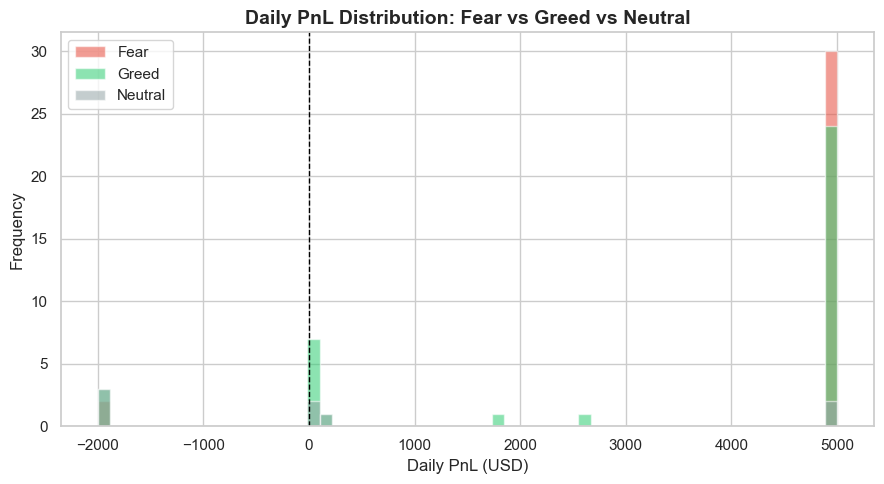

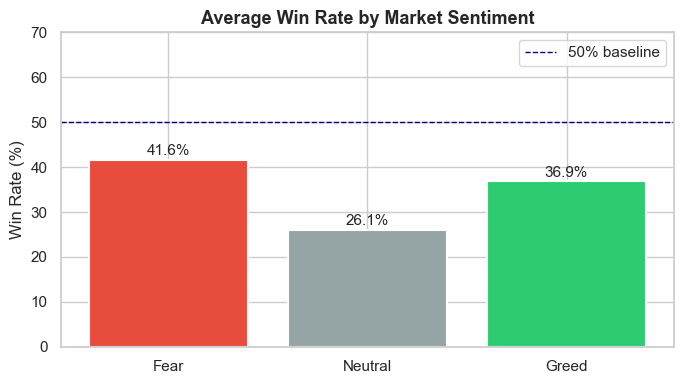

In [6]:
colors = {'Fear':'#e74c3c','Greed':'#2ecc71','Neutral':'#95a5a6'}
sent_order = ['Fear','Neutral','Greed']

# Summary table
q1 = daily.groupby('sentiment')[['daily_pnl','win_rate','trade_count','avg_size','long_ratio']].mean().round(3)
print(q1)

# Chart 1: PnL distribution
fig, ax = plt.subplots(figsize=(9,5))
for s, c in colors.items():
    daily[daily['sentiment']==s]['daily_pnl'].clip(-2000,5000).plot(
        kind='hist', bins=60, alpha=0.55, color=c, label=s, ax=ax)
ax.set_title('Daily PnL Distribution: Fear vs Greed vs Neutral', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily PnL (USD)'); ax.set_ylabel('Frequency')
ax.legend(); ax.axvline(0, color='black', linewidth=1, linestyle='--')
plt.tight_layout(); plt.savefig('chart1_pnl_dist.png', dpi=150); plt.show()

# Chart 4: Win rate
fig, ax = plt.subplots(figsize=(7,4))
wr = daily.groupby('sentiment')['win_rate'].mean().reindex(sent_order)*100
bars = ax.bar(sent_order, wr.values, color=[colors[s] for s in sent_order], edgecolor='white', lw=1.5)
ax.axhline(50, color='navy', linestyle='--', linewidth=1, label='50% baseline')
ax.set_title('Average Win Rate by Market Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Win Rate (%)'); ax.set_ylim(0,70); ax.legend()
for bar, v in zip(bars, wr.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{v:.1f}%', ha='center', fontsize=11)
plt.tight_layout(); plt.savefig('chart4_winrate.png', dpi=150); plt.show()


### Q2: Do traders change behavior based on sentiment?

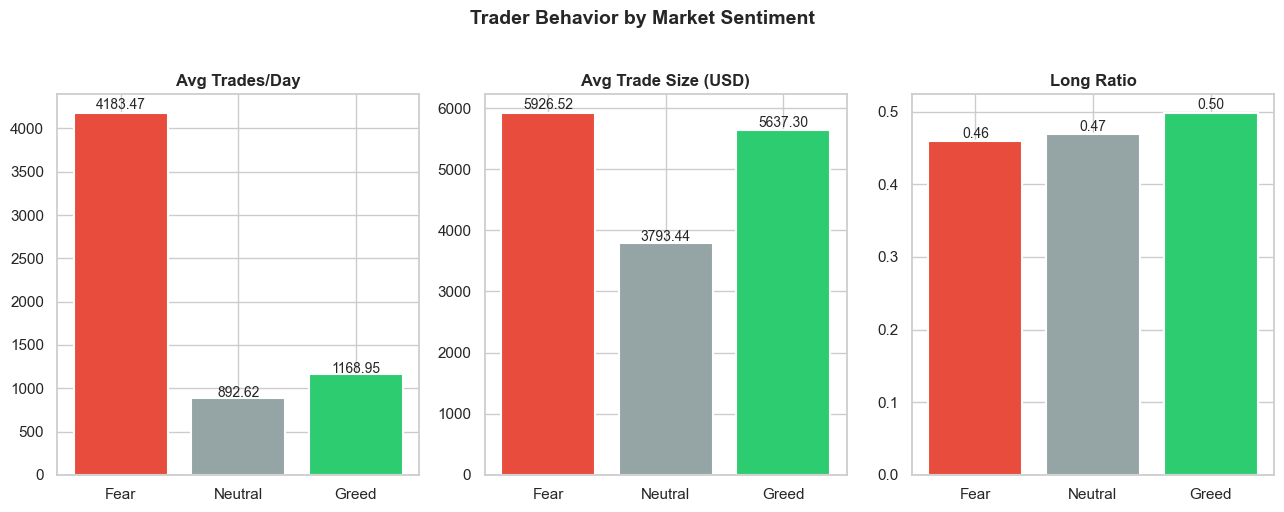

In [7]:
fig, axes = plt.subplots(1,3, figsize=(13,5))
metrics = [('trade_count','Avg Trades/Day'),('avg_size','Avg Trade Size (USD)'),('long_ratio','Long Ratio')]
for ax, (col, label) in zip(axes, metrics):
    vals = daily.groupby('sentiment')[col].mean().reindex(sent_order)
    bars = ax.bar(sent_order, vals.values, color=[colors[s] for s in sent_order], edgecolor='white', lw=1.5)
    ax.set_title(label, fontsize=12, fontweight='bold')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'{v:.2f}', ha='center', fontsize=10)
plt.suptitle('Trader Behavior by Market Sentiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('chart2_behavior.png', dpi=150, bbox_inches='tight'); plt.show()


### Q3: Trader Segments

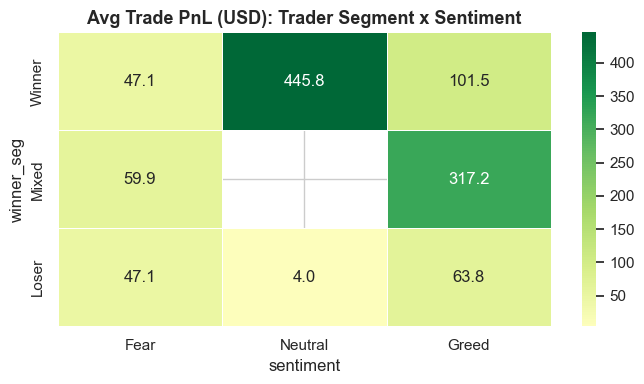

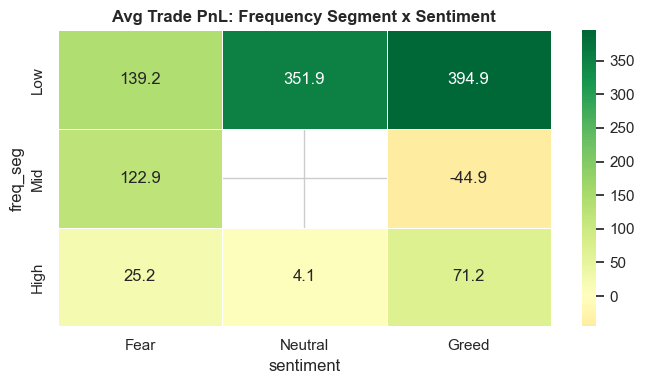

In [8]:
# Heatmap: Winner Segment x Sentiment
hm = merged2.groupby(['winner_seg','sentiment'])['Closed PnL'].mean().unstack().reindex(
    index=['Winner','Mixed','Loser'], columns=['Fear','Neutral','Greed'])
fig, ax = plt.subplots(figsize=(7,4))
sns.heatmap(hm, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax)
ax.set_title('Avg Trade PnL (USD): Trader Segment x Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('chart3_heatmap.png', dpi=150); plt.show()

# Heatmap: Frequency Segment x Sentiment
hm2 = merged2.groupby(['freq_seg','sentiment'])['Closed PnL'].mean().unstack().reindex(
    index=['Low','Mid','High'], columns=['Fear','Neutral','Greed'])
fig, ax = plt.subplots(figsize=(7,4))
sns.heatmap(hm2, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax)
ax.set_title('Avg Trade PnL: Frequency Segment x Sentiment', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('chart5_freq_heatmap.png', dpi=150); plt.show()


## Part C — Actionable Output

### Strategy Rule 1 — Fear Days: Low-Frequency Traders Should Stay Active
**Finding:** Low-frequency traders earn avg **$139 PnL/trade on Fear days** vs only $25 for high-frequency traders.  
**Rule:** On Fear days (F&G index < 40), low-frequency traders should **maintain normal position sizes** and not panic-reduce. High-frequency traders should **cut trade count by 30–40%** to avoid noise.

### Strategy Rule 2 — Greed Days: Winners Shine, Mid-Frequency Traders Underperform
**Finding:** On Greed days, "Winner" segment earns $101/trade avg; "Mid" frequency traders actually go **negative (−$44.93)**.  
**Rule:** On Greed days (F&G index > 60), consistent winners (win_rate > 55%) can **increase position sizes by up to 20%**. Mid-frequency traders should apply strict stop-losses as overconfidence risk is highest.


## Bonus — KMeans Trader Clustering

             win_rate  trade_count  avg_size   total_pnl
Archetype 0      0.31      4144.25   3699.54   131450.72
Archetype 1      0.50      3097.15   4103.10   194466.96
Archetype 2      0.41     24044.67   2984.30  1264087.54
Archetype 3      0.39      5533.75  20782.26   581876.97


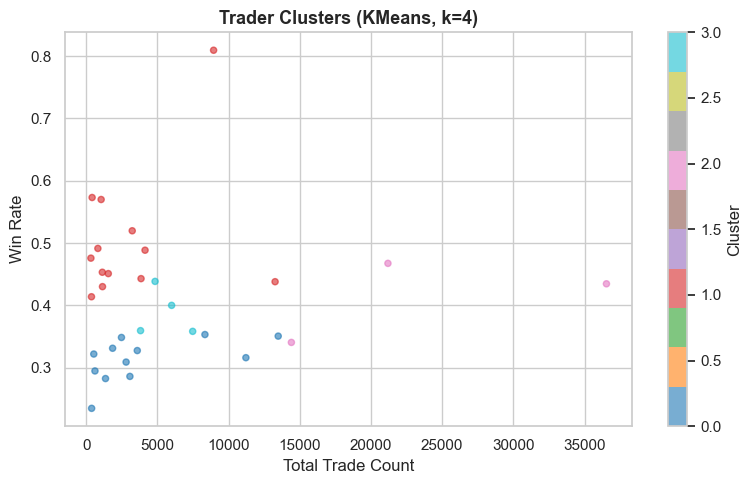

In [9]:
# Cluster traders into behavioral archetypes
features = tp[['win_rate','trade_count','avg_size','total_pnl']].fillna(0)
scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
tp['cluster'] = kmeans.fit_predict(X)

cluster_summary = tp.groupby('cluster')[['win_rate','trade_count','avg_size','total_pnl']].mean().round(2)
cluster_summary.index = ['Archetype ' + str(i) for i in cluster_summary.index]
print(cluster_summary)

# Scatter plot
fig, ax = plt.subplots(figsize=(8,5))
scatter = ax.scatter(tp['trade_count'], tp['win_rate'],
                     c=tp['cluster'], cmap='tab10', alpha=0.6, s=20)
ax.set_xlabel('Total Trade Count'); ax.set_ylabel('Win Rate')
ax.set_title('Trader Clusters (KMeans, k=4)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout(); plt.savefig('chart6_clusters.png', dpi=150); plt.show()
